In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("googleplaystore.csv")

In [3]:
# Data Cleaning
df['Installs'] = pd.to_numeric(df['Installs'].astype(str).str.replace('+','',regex=False).str.replace(',','',regex=False).str.replace('Free','',regex=False), errors='coerce')
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace('Free','0',regex=False).str.replace('$','',regex=False).str.replace('Everyone','',regex=False), errors='coerce')
df['Size'] = df['Size'].replace('Varies with device', np.nan)

In [4]:
# Convert Size to MB
def size_to_mb(x):
    if pd.isnull(x): return np.nan
    x_str = str(x) # Convert x to string for safe string operations
    if 'M' in x_str: return float(x_str.replace('M',''))
    if 'k' in x_str: return float(x_str.replace('k',''))/1024
    return np.nan
df['Size'] = df['Size'].apply(size_to_mb)

In [5]:
# Convert Last Updated to datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

In [6]:
# Handle missing ratings
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

**Basic Questions**

In [7]:
# 1. Average rating
print("Average Rating:", df['Rating'].mean())

Average Rating: 4.193338315362443


In [8]:
# 2. Unique categories
print("Unique Categories:", df['Category'].nunique())

Unique Categories: 34


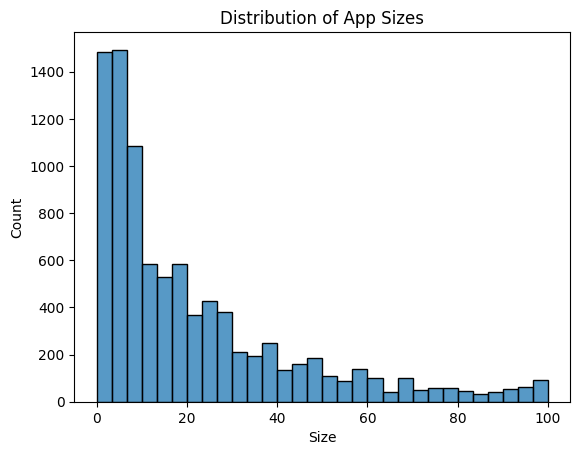

In [9]:
# 3. Distribution of app sizes
sns.histplot(df['Size'].dropna(), bins=30)
plt.title("Distribution of App Sizes")
plt.show()

In [10]:
# 4. Free vs Paid apps
print(df['Type'].value_counts())

Type
Free    10039
Paid      800
0           1
Name: count, dtype: int64


In [11]:
# 5. Most common content rating
print("Most Common Content Rating:", df['Content Rating'].mode()[0])

Most Common Content Rating: Everyone


In [12]:
# 6. Top 5 most installed apps
print(df.sort_values('Installs', ascending=False).head(5)[['App','Installs']])

                            App      Installs
2808              Google Photos  1.000000e+09
2853              Google Photos  1.000000e+09
3223  Maps - Navigate & Explore  1.000000e+09
3117  Maps - Navigate & Explore  1.000000e+09
3234                     Google  1.000000e+09


In [13]:
# 7. Apps with rating >= 4
print("Apps with rating >= 4:", df[df['Rating']>=4].shape[0])

Apps with rating >= 4: 7369


In [14]:
# 8. Average reviews free vs paid
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
print(df.groupby('Type')['Reviews'].mean())

Type
0                 NaN
Free    478661.096026
Paid     11673.312500
Name: Reviews, dtype: float64


In [15]:
# 9. Average app size per category
print(df.groupby('Category')['Size'].mean())

Category
1.9                          NaN
ART_AND_DESIGN         12.370968
AUTO_AND_VEHICLES      20.036807
BEAUTY                 13.795745
BOOKS_AND_REFERENCE    13.310188
BUSINESS               14.471877
COMICS                 13.484869
COMMUNICATION          11.765673
DATING                 16.625555
EDUCATION              20.790600
ENTERTAINMENT          21.853333
EVENTS                 13.963617
FAMILY                 28.319023
FINANCE                17.928309
FOOD_AND_DRINK         22.185000
GAME                   44.370065
HEALTH_AND_FITNESS     22.768851
HOUSE_AND_HOME         15.978539
LIBRARIES_AND_DEMO     11.079353
LIFESTYLE              14.754111
MAPS_AND_NAVIGATION    16.614368
MEDICAL                19.628456
NEWS_AND_MAGAZINES     13.023615
PARENTING              22.512963
PERSONALIZATION        11.297414
PHOTOGRAPHY            17.367574
PRODUCTIVITY           12.980885
SHOPPING               16.175059
SOCIAL                 17.681671
SPORTS                 24.338822
T

In [16]:
# 10. Apps updated in 2018
print("Apps updated in 2018:", df[df['Last Updated'].dt.year==2018].shape[0])

Apps updated in 2018: 7349


**Medium Questions**

In [17]:
# 1. Correlation installs vs rating
print("Correlation:", df['Installs'].corr(df['Rating']))

Correlation: 0.05135456605599932


In [18]:
# 2. Categories with highest avg rating
print(df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head())


Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
Name: Rating, dtype: float64


In [19]:
# 3. Price vs rating (paid apps only)
print(df[df['Type']=="Paid"].groupby('Price')['Rating'].mean())


Price
0.99      4.298131
1.00      4.450000
1.04           NaN
1.20      4.200000
1.26           NaN
            ...   
379.99    2.900000
389.99    3.600000
394.99         NaN
399.99    4.009091
400.00    3.600000
Name: Rating, Length: 91, dtype: float64


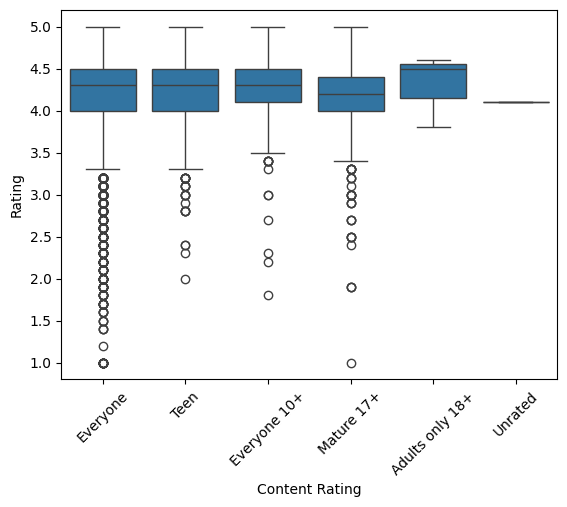

In [20]:
# 4. Rating distribution by content rating
sns.boxplot(x='Content Rating', y='Rating', data=df)
plt.xticks(rotation=45)
plt.show()

In [21]:
# 5. Genres with >1M installs
print(df[df['Installs']>1e6].groupby('Genres').size().sort_values(ascending=False).head())

Genres
Action           190
Tools            187
Photography      172
Communication    167
Productivity     138
dtype: int64


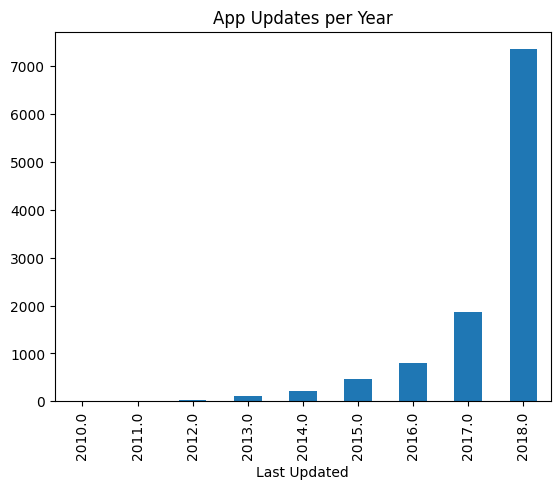

In [22]:
# 6. Update frequency
updates = df['Last Updated'].dt.year.value_counts().sort_index()
updates.plot(kind='bar')
plt.title("App Updates per Year")
plt.show()


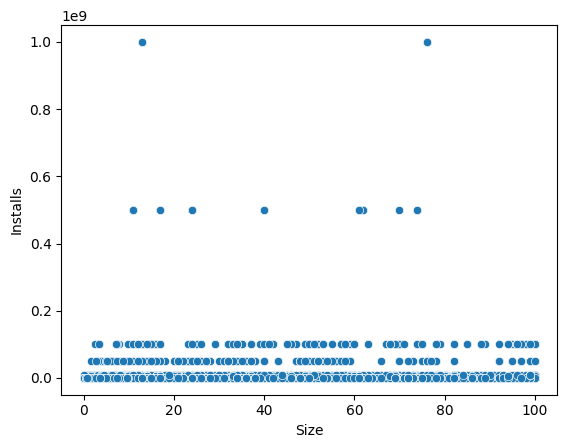

In [23]:
# 7. Impact of size on installs
sns.scatterplot(x='Size', y='Installs', data=df)
plt.show()

In [24]:
# 8. Apps with highest reviews
print(df.sort_values('Reviews', ascending=False).head(5)[['App','Reviews','Rating']])


                     App     Reviews  Rating
2544            Facebook  78158306.0     4.1
3943            Facebook  78128208.0     4.1
381   WhatsApp Messenger  69119316.0     4.4
336   WhatsApp Messenger  69119316.0     4.4
3904  WhatsApp Messenger  69109672.0     4.4


In [25]:
# 9. Content rating distribution free vs paid
print(pd.crosstab(df['Content Rating'], df['Type']))


Type             Free  Paid
Content Rating             
Adults only 18+     3     0
Everyone         8019   695
Everyone 10+      380    33
Mature 17+        479    20
Teen             1156    52
Unrated             2     0


In [26]:
# 10. Top 5 categories by installs
print(df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(5))


Category
GAME             3.508602e+10
COMMUNICATION    3.264728e+10
PRODUCTIVITY     1.417609e+10
SOCIAL           1.406987e+10
TOOLS            1.145277e+10
Name: Installs, dtype: float64


**Advanced Questions**

In [27]:
# 1. Top 10 highest rated apps
print(df.sort_values('Rating', ascending=False).head(10)[['App','Rating','Reviews','Installs']])


                                           App  Rating  Reviews  Installs
10472  Life Made WI-Fi Touchscreen Photo Frame    19.0      NaN       NaN
9089                                   DYPSOET     5.0      8.0      50.0
9061                 Cloud DX Connected Health     5.0      6.0     100.0
9056               Santa's Monster Shootout DX     5.0      4.0      50.0
9039                             Chronolink DX     5.0      7.0      10.0
9010                     RETRO Shocked DW-6000     5.0     13.0     100.0
9008                                  DW Timer     5.0      9.0     100.0
9002                               DW Security     5.0      6.0     100.0
6422                        BL Flowers Digital     5.0     21.0     100.0
6372                     BK Formula Calculator     5.0      6.0     100.0


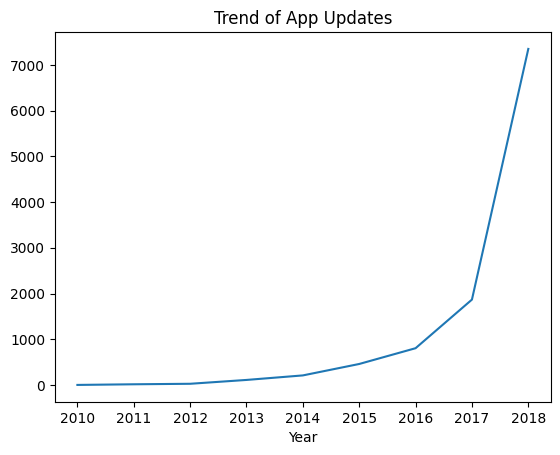

In [28]:
# 2. Trend of updates over time
df['Year'] = df['Last Updated'].dt.year
df['Year'].value_counts().sort_index().plot(kind='line')
plt.title("Trend of App Updates")
plt.show()


In [29]:
# 3. Rating change with installs (binned)
df['Install_Bin'] = pd.cut(df['Installs'], bins=[0,1e3,1e5,1e6,1e7,1e8], labels=['<1k','1k-100k','100k-1M','1M-10M','10M+'])
print(df.groupby('Install_Bin')['Rating'].mean())


Install_Bin
<1k        4.198897
1k-100k    4.065839
100k-1M    4.207470
1M-10M     4.287076
10M+       4.386533
Name: Rating, dtype: float64


/tmp/ipykernel_463/61056256.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Install_Bin')['Rating'].mean())


In [30]:
# 4. Sentiment analysis (if review text available)
# Example placeholder (assuming 'Review_Text' column exists)
# from textblob import TextBlob
# df['Sentiment'] = df['Review_Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)


In [31]:
# 5. Genre vs rating
print(df.groupby('Genres')['Rating'].mean().sort_values(ascending=False).head())


Genres
February 11, 2018             19.0
Board;Pretend Play             4.8
Comics;Creativity              4.8
Health & Fitness;Education     4.7
Puzzle;Education               4.6
Name: Rating, dtype: float64


 Additional Considerations

- Ethical & Privacy Concerns: When analyzing user reviews or personal data, it is critical to maintain privacy and comply with data protection standards. Predictive models should be checked for bias and fairness to ensure responsible outcomes.
- Interdisciplinary Collaboration: Collaboration with app developers, product managers, marketing teams, and domain experts is essential to validate findings and refine strategies.
- Continuous Improvement: The dataset and dashboards should be updated regularly. Models and insights must be refined based on new installs, ratings, and reviews to keep the analysis relevant and actionable.


Deliverables


- Case Study Document
- Problem statement
- Dataset description and data dictionary
- Data cleaning steps (handling missing values, type conversion, duplicates, text standardization, date formatting)
- Answers to all Basic, Medium, and Advanced questions with supporting visuals
- Solution Guide
- Python notebook with EDA code for each question
- Tableau dashboard with KPIs, bar charts, scatter plots, histograms, boxplots, and line charts
- Insights written in markdown cells or text boxes
- Insights Report
- Free apps dominate → monetization strategy is needed
- Games & Communication → highest installs
- Education & Events → highest ratings
- Paid apps have fewer installs but better ratings → premium niche strategy
- Frequent updates → maintain relevance and user engagement
- Additional Resources
- Kaggle dataset link


Desired Outcome

- Develop Analytical Mindset: Trainees learn to logically break down data and identify meaningful patterns.
- Decision Support: Insights provide clear guidance for product managers and developers to improve app strategies.
- Understand User Preferences: Identify which categories and content ratings are most popular among users.
- Align Business Strategy: Free vs Paid split, pricing impact, and update cycles support better business decisions.
- Benchmarking: Average rating and installs serve as baselines for new apps to set quality standards.
- Continuous Improvement: Regularly update analysis with new data, refine dashboards, and improve strategies based on user feedback.
